## Average Filling (AF)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
p1 = "../Dataset/ml-100k/u1.base"
p2 = "../Dataset/ml-100k/u1.test"

# u2 test
# p1 = "../Dataset/ml-100k/u2.base"
# p2 = "../Dataset/ml-100k/u2.test"


df1 = pd.read_csv(p1, sep='\t',
                 names=['user_id', 'item_id', 'rating', 'timestamp'])
print(df1.head())

df2 = pd.read_csv(p2,sep='\t',
                  names=['user_id','item_id','rating','timestamp'])
print(df2.head())



   user_id  item_id  rating  timestamp
0        1        1       5  874965758
1        1        2       3  876893171
2        1        3       4  878542960
3        1        4       3  876893119
4        1        5       3  889751712
   user_id  item_id  rating  timestamp
0        1        6       5  887431973
1        1       10       3  875693118
2        1       12       5  878542960
3        1       14       5  874965706
4        1       17       3  875073198


In [6]:
# Preparations
user_ratings = {} # {user_id:[rating1,rating2,...]}
item_ratings = {} # {item_id:[rating1,rating2,...]}
for (u,i,r,ts) in df1.values:
    if u not in user_ratings:
        user_ratings[u] = []
    user_ratings[u].append(r)
    if i not in item_ratings:
        item_ratings[i] = []
    item_ratings[i].append(r)
    
print(user_ratings)
print(item_ratings)

{np.int64(1): [np.int64(5), np.int64(3), np.int64(4), np.int64(3), np.int64(3), np.int64(4), np.int64(1), np.int64(5), np.int64(2), np.int64(5), np.int64(5), np.int64(5), np.int64(4), np.int64(5), np.int64(1), np.int64(4), np.int64(4), np.int64(3), np.int64(4), np.int64(1), np.int64(3), np.int64(5), np.int64(2), np.int64(1), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(5), np.int64(4), np.int64(5), np.int64(4), np.int64(5), np.int64(5), np.int64(4), np.int64(5), np.int64(5), np.int64(4), np.int64(5), np.int64(2), np.int64(4), np.int64(4), np.int64(3), np.int64(4), np.int64(4), np.int64(4), np.int64(3), np.int64(5), np.int64(4), np.int64(5), np.int64(5), np.int64(2), np.int64(4), np.int64(3), np.int64(2), np.int64(2), np.int64(4), np.int64(5), np.int64(1), np.int64(5), np.int64(5), np.int64(3), np.int64(5), np.int64(3), np.int64(4), np.int64(5), np.int64(2), np.int64(5), np.int64(1), np.int64(4), np.int64(4), np.int64(3), np.int64(5), np.int64(1), np.int64(3), np.int64(3

In [4]:
# 计算全局平均评分
# mu = df1['rating'].mean()

total = 0
count = 0
for (u,i,r,ts) in df1.values:
    total += r
    count += 1
mu = total / count

print(mu)


3.52835


In [5]:
# 计算用户的平均评分
# user_mean = df1.groupby('user_id')['rating'].mean()

user_mean = {}
for u,rating_list in user_ratings.items():
    user_mean[u] = sum(rating_list) / len(rating_list)

print(user_mean)


# 计算物品的平均评分
# item_mean = df1.groupby('item_id')['rating'].mean()

item_mean = {}
for i,rating_list in item_ratings.items():
    item_mean[i] = sum(rating_list) / len(rating_list)

print(item_mean)

{np.int64(1): np.float64(3.6814814814814816), np.int64(2): np.float64(3.8), np.int64(3): np.float64(3.0), np.int64(4): np.float64(4.357142857142857), np.int64(5): np.float64(2.956043956043956), np.int64(6): np.float64(3.581818181818182), np.int64(7): np.float64(3.892018779342723), np.int64(8): np.float64(3.6), np.int64(9): np.float64(4.166666666666667), np.int64(10): np.float64(4.212765957446808), np.int64(11): np.float64(3.533333333333333), np.int64(12): np.float64(4.28), np.int64(13): np.float64(3.136729222520107), np.int64(14): np.float64(4.219512195121951), np.int64(15): np.float64(3.033333333333333), np.int64(16): np.float64(4.3478260869565215), np.int64(17): np.float64(3.1578947368421053), np.int64(18): np.float64(3.9371069182389937), np.int64(19): np.float64(3.6), np.int64(20): np.float64(3.3076923076923075), np.int64(21): np.float64(2.663157894736842), np.int64(22): np.float64(3.3), np.int64(23): np.float64(3.6363636363636362), np.int64(24): np.float64(4.390243902439025), np.in

In [6]:
# 计算用户u的偏置

b_u = {}
for u,i,r,ts in df1.values:
    if u not in b_u:
        b_u[u] = {'numerator':0.0,'count':0}
    b_u[u]['numerator'] += r - item_mean[i]
    b_u[u]['count'] += 1
    
for u in b_u:
    b_u[u] = b_u[u]['numerator'] / b_u[u]['count']

print(b_u)

{np.int64(1): np.float64(0.10895209718594022), np.int64(2): np.float64(0.1472927222680549), np.int64(3): np.float64(-0.2960898557911533), np.int64(4): np.float64(0.9958615907612559), np.int64(5): np.float64(-0.3079792726851744), np.int64(6): np.float64(-0.2132164488042467), np.int64(7): np.float64(0.4176132607227074), np.int64(8): np.float64(0.15524458244620726), np.int64(9): np.float64(0.4378162257618234), np.int64(10): np.float64(0.39320887433791984), np.int64(11): np.float64(-0.03148505001076942), np.int64(12): np.float64(0.48557403126553544), np.int64(13): np.float64(-0.2042770133679941), np.int64(14): np.float64(0.45370913289411335), np.int64(15): np.float64(-0.3786702652465309), np.int64(16): np.float64(0.6836290048589253), np.int64(17): np.float64(-0.4517566041338588), np.int64(18): np.float64(0.1904663627084601), np.int64(19): np.float64(0.05305170754180555), np.int64(20): np.float64(-0.3503286025039967), np.int64(21): np.float64(-0.2613751620050546), np.int64(22): np.float64(-

In [7]:
# 计算物品i的偏置

b_i = {}
for u,i,r,ts in df1.values:
    if i not in b_i:
        b_i[i] = {'numerator':0.0,'count':0}
    b_i[i]['numerator'] += r - user_mean[u]
    b_i[i]['count'] += 1

for i in b_i:
    b_i[i] = b_i[i]['numerator'] / b_i[i]['count']

print(b_i)

{np.int64(1): np.float64(0.3151815740620171), np.int64(2): np.float64(-0.2884956106111347), np.int64(3): np.float64(-0.46447784593369346), np.int64(4): np.float64(-0.04349892060737127), np.int64(5): np.float64(-0.20799934460834707), np.int64(7): np.float64(0.253015056329072), np.int64(8): np.float64(0.3853246359967076), np.int64(9): np.float64(0.25318123023732286), np.int64(11): np.float64(0.2667205526808538), np.int64(13): np.float64(-0.11808799682529718), np.int64(15): np.float64(0.2152921009461531), np.int64(16): np.float64(-0.170954434894903), np.int64(18): np.float64(-0.374333586895178), np.int64(19): np.float64(0.3862119913523766), np.int64(21): np.float64(-0.6408629317095883), np.int64(22): np.float64(0.5492494607116921), np.int64(25): np.float64(-0.09341508407935278), np.int64(26): np.float64(-0.19266011742430605), np.int64(28): np.float64(0.3382444771533452), np.int64(29): np.float64(-0.778716009506923), np.int64(30): np.float64(0.4459788812469584), np.int64(32): np.float64(0.

### Prediction Rules

In [8]:
records = []   # Each (u, i, actual, pred1, pred2, ..., pred6)

for u, i, r, ts in df2.values:

    um = user_mean.get(u,mu)
    im = item_mean.get(i,mu)
    bu = b_u.get(u,0.0)
    bi = b_i.get(i,0.0)

    p1 = um                    # 用户平均
    p2 = im                    # 物品平均
    p3 = (um + im) / 2         # 两者均值
    p4 = bu + im               # 用户偏置+用户平均
    p5 = um + bi               # 用户平均+物品偏置
    p6 = mu + bu + bi          # 全局+用户偏置+物品偏置
    records.append((u, i, r, p1, p2, p3, p4, p5, p6))

result = pd.DataFrame(records, columns=['user','item','actual','p1_user','p2_item','p3_avg','p4_bu_umean','p5_umean_bi','p6_mu_bu_bi'])
print(result)




       user  item  actual   p1_user   p2_item    p3_avg  p4_bu_umean  \
0         1     6       5  3.681481  3.400000  3.540741     3.508952   
1         1    10       3  3.681481  3.876712  3.779097     3.985664   
2         1    12       5  3.681481  4.398104  4.039793     4.507056   
3         1    14       5  3.681481  3.900000  3.790741     4.008952   
4         1    17       3  3.681481  3.180556  3.431019     3.289508   
...     ...   ...     ...       ...       ...       ...          ...   
19995   458   648       4  3.683333  3.962963  3.823148     3.910740   
19996   458  1101       4  3.683333  3.724138  3.703736     3.671915   
19997   459   934       3  3.384615  2.901639  3.143127     2.927673   
19998   460    10       3  3.417910  3.876712  3.647311     3.691139   
19999   462   682       5  3.968750  3.065789  3.517270     3.607549   

       p5_umean_bi  p6_mu_bu_bi  
0         3.705298     3.661118  
1         3.960264     3.916084  
2         4.486486     4.442307  

In [9]:
cols = ['p1_user', 'p2_item', 'p3_avg', 'p4_bu_umean', 'p5_umean_bi', 'p6_mu_bu_bi']

mae_results = {}
rmse_results = {}
for col in cols:
    mae_results[col] = (abs(result[col] - result['actual'])).mean()
    rmse_results[col] = ((result[col] - result['actual'])**2).mean() ** 0.5

print("MAE:")
for k, v in mae_results.items():
    print(f"  {k}: {v:.4f}")
print("RMSE:")
for k, v in rmse_results.items():
    print(f"  {k}: {v:.4f}")

p1_user_mae = mae_results[cols[0]]
p2_item_mae = mae_results[cols[1]]
p3_avg_mae = mae_results[cols[2]]
p4_bu_umean_mae = mae_results[cols[3]]
p5_umean_bi_mae = mae_results[cols[4]]
p6_mu_bu_bi_mae = mae_results[cols[5]]

p1_user_rmse = rmse_results[cols[0]]
p2_item_rmse = rmse_results[cols[1]]
p3_avg_rmse = rmse_results[cols[2]]
p4_bu_umean_rmse = rmse_results[cols[3]]
p5_umean_bi_rmse = rmse_results[cols[4]]
p6_mu_bu_bi_rmse = rmse_results[cols[5]]

# The smaller the better.

MAE:
  p1_user: 0.8502
  p2_item: 0.8276
  p3_avg: 0.8085
  p4_bu_umean: 0.7574
  p5_umean_bi: 0.7696
  p6_mu_bu_bi: 0.7613
RMSE:
  p1_user: 1.0630
  p2_item: 1.0334
  p3_avg: 0.9985
  p4_bu_umean: 0.9602
  p5_umean_bi: 0.9758
  p6_mu_bu_bi: 0.9623


### 结果绘图

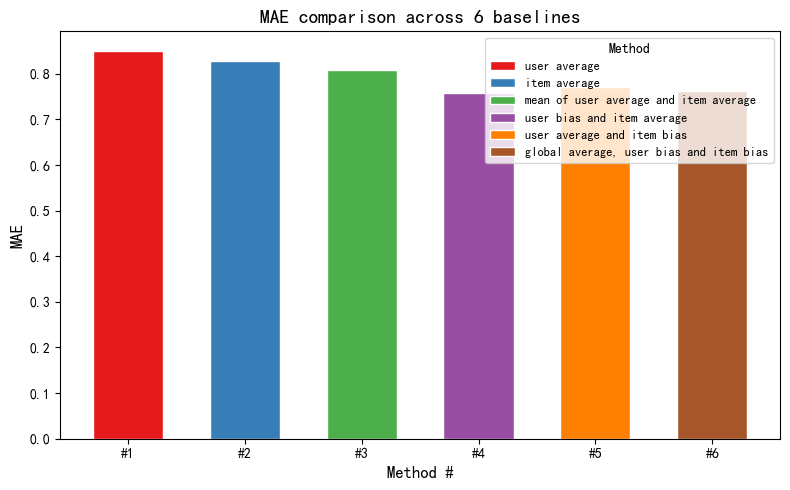

In [10]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False    

labels = ['user average', 'item average', 'mean of user average and item average', 'user bias and item average',
          'user average and item bias','global average, user bias and item bias']
values = [p1_user_mae,p2_item_mae,p3_avg_mae,p4_bu_umean_mae,p5_umean_bi_mae,p6_mu_bu_bi_mae]

colors = ['#e41a1c', '#377eb8', '#4daf4a',
          '#984ea3', '#ff7f00', '#a65628']

x = np.arange(len(labels))
bar_width = 0.6

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(len(labels)):
    ax.bar(x[i], values[i], width=bar_width,
           color=colors[i], edgecolor='white',
           label=labels[i])

ax.set_xticks(x)
ax.set_xticklabels([f'#{i+1}' for i in range(len(labels))])

ax.set_title('MAE comparison across 6 baselines', fontsize=14)
ax.set_xlabel('Method #', fontsize=12)
ax.set_ylabel('MAE', fontsize=12)

ax.legend(fontsize=9, title='Method', title_fontsize=10)

plt.tight_layout()
plt.show()

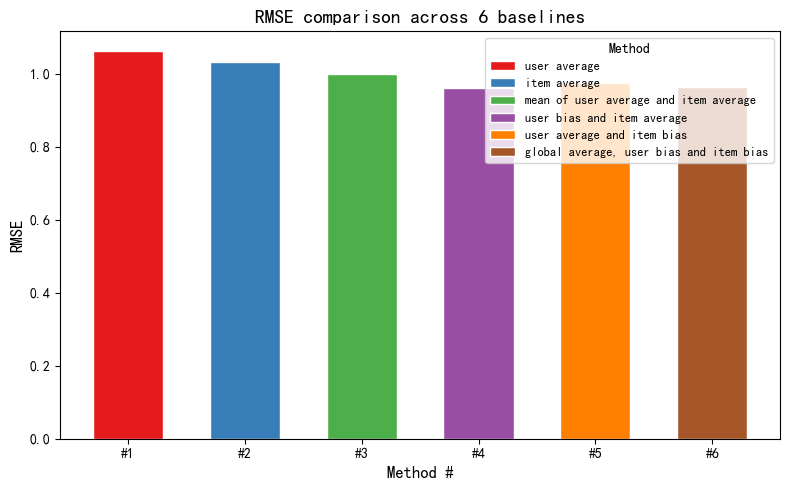

In [11]:
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False    

labels = ['user average', 'item average', 'mean of user average and item average', 'user bias and item average',
          'user average and item bias','global average, user bias and item bias']
values = [p1_user_rmse,p2_item_rmse,p3_avg_rmse,p4_bu_umean_rmse,p5_umean_bi_rmse,p6_mu_bu_bi_rmse]

colors = ['#e41a1c', '#377eb8', '#4daf4a',
          '#984ea3', '#ff7f00', '#a65628']

x = np.arange(len(labels))
bar_width = 0.6

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(len(labels)):
    ax.bar(x[i], values[i], width=bar_width,
           color=colors[i], edgecolor='white',
           label=labels[i])

ax.set_xticks(x)
ax.set_xticklabels([f'#{i+1}' for i in range(len(labels))])

ax.set_title('RMSE comparison across 6 baselines', fontsize=14)
ax.set_xlabel('Method #', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)

ax.legend(fontsize=9, title='Method', title_fontsize=10)

plt.tight_layout()
plt.show()